# Iris Flower Classification

A complete machine learning workflow to classify Iris flowers (**Setosa**, **Versicolor**, **Virginica**) using their sepal and petal measurements.

**Steps covered:**
1. Load and explore the dataset
2. Visualize the data
3. Preprocess (train/test split, scaling)
4. Train multiple classification models
5. Evaluate performance (accuracy, confusion matrix, classification report)
6. Understand which features matter most


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
%matplotlib inline


## 2. Load the Dataset

The dataset (`Iris.csv`) contains 150 samples with 4 measurements each (sepal length/width, petal length/width in cm) and a species label.

> Place `Iris.csv` in the same folder as this notebook (or update the path below). This is the classic Iris dataset, originally collected by Ronald Fisher (1936) and widely available via [Kaggle](https://www.kaggle.com/datasets/uciml/iris) or `sklearn.datasets.load_iris()`.


In [2]:
df = pd.read_csv(r"C:\Users\gchar\Downloads\Iris.csv")

# Drop the Id column if present -- it's not a real feature
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

print("Shape:", df.shape)
df.head()


Shape: (150, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB


In [4]:
df.describe()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
print("Class distribution:")
df["Species"].value_counts()


Class distribution:


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## 3. Exploratory Data Analysis

Let's visualize the relationships between features to see how separable the three species are.


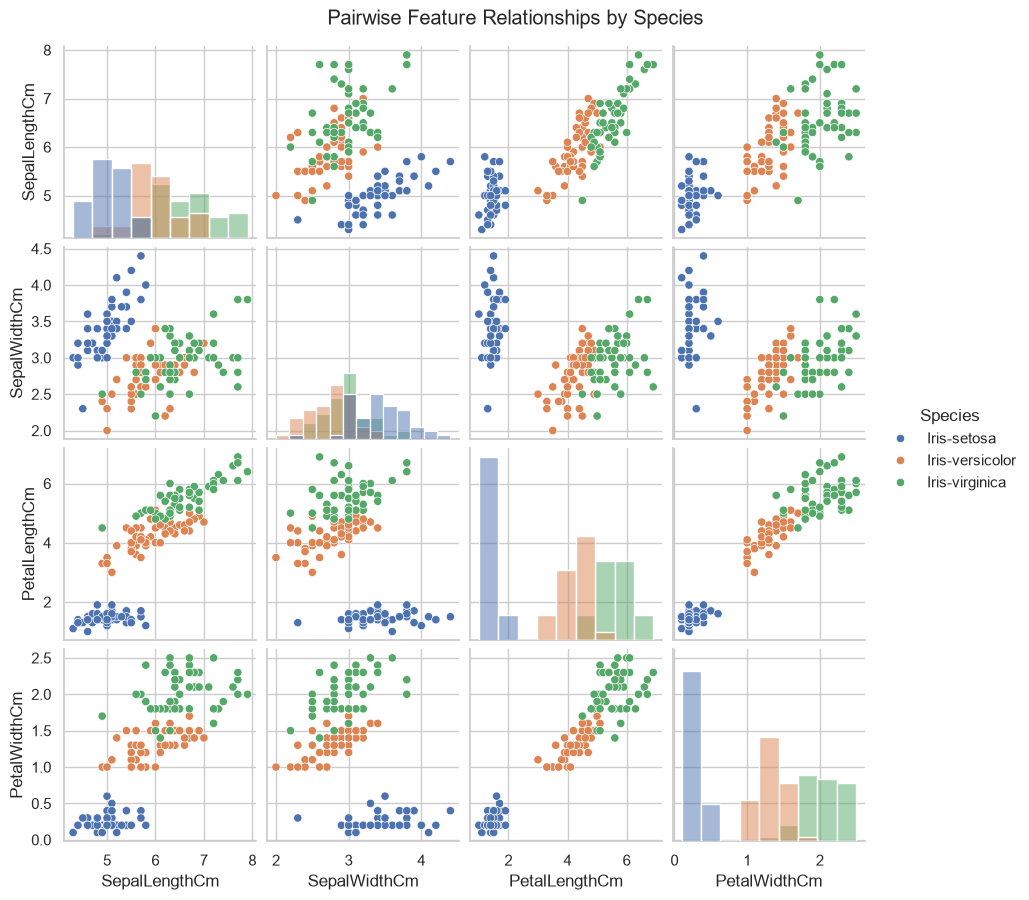

In [7]:
sns.pairplot(df, hue="Species", diag_kind="hist", height=2.2)
plt.suptitle("Pairwise Feature Relationships by Species", y=1.02)
plt.show()


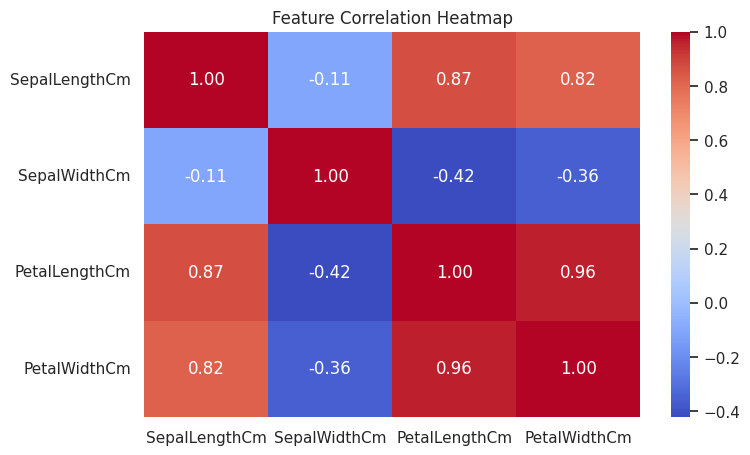

In [7]:
plt.figure(figsize=(8, 5))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


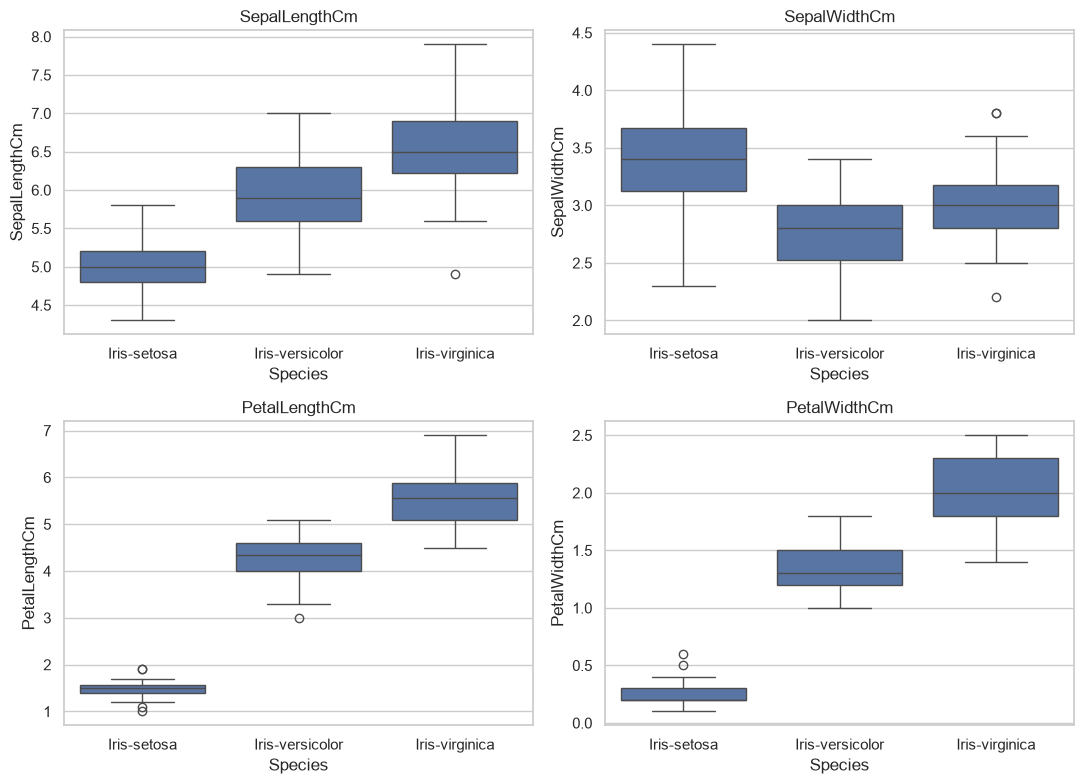

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="Species", y=feat, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()


**Observation:** Petal length and petal width separate the species much more cleanly than sepal measurements -- Setosa in particular is linearly separable from the other two on these features.


## 4. Preprocessing

- Encode the species labels as integers
- Split into train/test sets (80/20, stratified so class proportions are preserved)
- Scale features (helps distance-based/gradient-based models like KNN, SVM, Logistic Regression)


In [9]:
X = df.drop(columns=["Species"])
y = df["Species"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(dict(zip(le.classes_, le.transform(le.classes_))))


{'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])


Train size: 120 | Test size: 30


## 5. Train Multiple Classification Models

We'll train a few standard classifiers and compare them:
- Logistic Regression
- K-Nearest Neighbors
- Support Vector Machine
- Decision Tree
- Random Forest


In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="linear"),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name:20s} accuracy: {acc:.4f}")


Logistic Regression  accuracy: 0.9333
KNN                  accuracy: 0.9333
SVM                  accuracy: 1.0000
Decision Tree        accuracy: 0.9000
Random Forest        accuracy: 0.9000


In [12]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"]).sort_values("Accuracy", ascending=False)
results_df


,Model,Accuracy
2,SVM,1.000000
0,Logistic Regression,0.933333
1,KNN,0.933333
3,Decision Tree,0.900000
4,Random Forest,0.900000


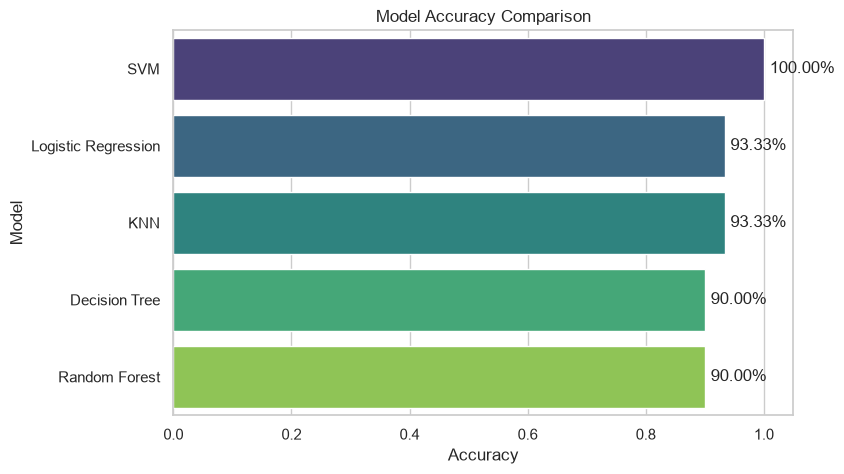

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Accuracy", y="Model", hue="Model", palette="viridis", legend=False)
plt.xlim(0, 1.05)
plt.title("Model Accuracy Comparison")
for i, v in enumerate(results_df["Accuracy"]):
    plt.text(v + 0.01, i, f"{v:.2%}", va="center")
plt.show()


## 6. Detailed Evaluation of the Best Model

Let's take a closer look at the top-performing model: confusion matrix and full classification report (precision, recall, F1-score per class).


In [14]:
best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]
best_preds = best_model.predict(X_test_scaled)

print(f"Best model: {best_name}")
print(f"Test Accuracy: {accuracy_score(y_test, best_preds):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, best_preds, target_names=le.classes_))


Best model: SVM
Test Accuracy: 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



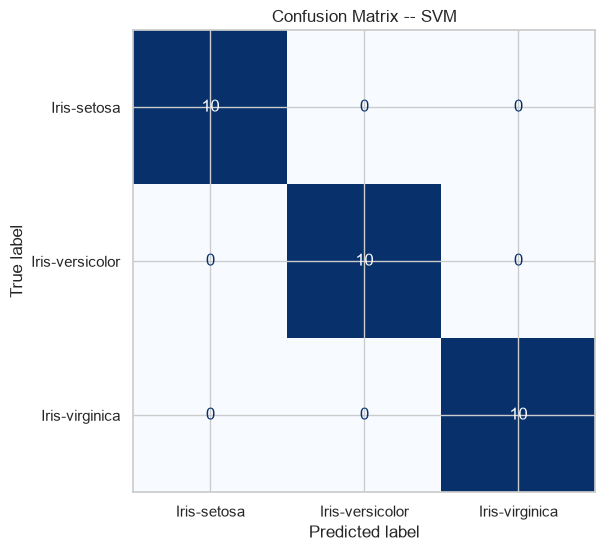

In [15]:
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix -- {best_name}")
plt.show()


## 7. Which Features Matter Most?

Using the Random Forest model, we can rank features by how much they contribute to correct classification.


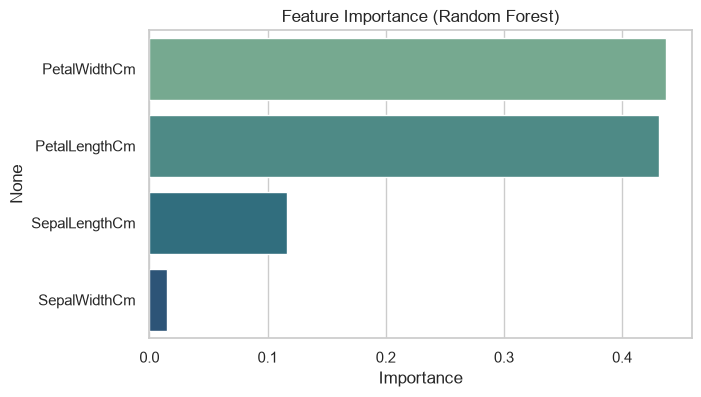

PetalWidthCm     0.437185
PetalLengthCm    0.431466
SepalLengthCm    0.116349
SepalWidthCm     0.015000
dtype: float64

In [16]:
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="crest", legend=False)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

importances


## 8. Predict on a New Sample

Example: classify a new, unseen flower measurement.


In [17]:
new_sample = pd.DataFrame(
    [[5.8, 2.7, 4.1, 1.0]],
    columns=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
)
new_sample_scaled = scaler.transform(new_sample)
pred_class = best_model.predict(new_sample_scaled)
pred_label = le.inverse_transform(pred_class)

print("Predicted species:", pred_label[0])


Predicted species: Iris-versicolor


## 9. Summary & Key ML Concepts

- **Classification**: predicting a discrete label (species) from input features -- as opposed to regression, which predicts continuous values.
- **Train/test split**: we hold out 20% of the data to fairly evaluate the model on data it hasn't seen.
- **Feature scaling**: standardizing features (mean 0, std 1) helps distance-based and gradient-based models converge and perform well.
- **Accuracy**: the fraction of correct predictions -- a good headline metric here since the classes are balanced (50 samples each).
- **Confusion matrix**: shows exactly which classes get confused with which -- in Iris, Versicolor and Virginica are the two species most likely to be mixed up; Setosa is almost always perfectly separated.
- **Precision / Recall / F1**: per-class metrics that matter more than plain accuracy when classes are imbalanced.
- **Feature importance**: petal length and petal width are typically the most predictive features for Iris classification, much more so than sepal measurements.

**Next steps to explore further:**
- Try cross-validation (`cross_val_score`) instead of a single train/test split for a more robust accuracy estimate.
- Tune hyperparameters with `GridSearchCV` (e.g., `n_neighbors` for KNN, `C`/`kernel` for SVM).
- Try dimensionality reduction (PCA) to visualize the 4D feature space in 2D.
